## Credit Risk Assessment with Machine Learning  

This project aims to develop a **machine learning model** that accurately assesses credit risk for loan applicants.  

Effective credit risk assessment is essential for financial institutions to:  
- Minimize losses from loan defaults  
- Make **data-driven lending decisions**  

---

### Predictable Findings  

The model evaluates how **housing status, loan grade, loan interest, and salary** influence the **payment cycle of the loan**.  

---

### Benefits for Lenders  

By predicting the probability of loan default, lenders can:  

- Approve or reject applications with greater confidence  
- Set more appropriate interest rates  
- Manage overall portfolio risk more effectively  

In [2]:
%pip install notebook jupyter ipykernel

In [3]:
%pip install -U ydata-profiling

   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   -------------------------------

In [4]:
%pip install pdfkit
%pip install weasyprint


Note: you may need to restart the kernel to use updated packages.


In [46]:
#data
import pandas as pd
import numpy as np
import pdfkit
import webbrowser
import tempfile
import os

#visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from IPython.display import IFrame
from IPython.display import HTML, display

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.under_sampling import ClusterCentroids
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.metrics import make_scorer, recall_score
from sklearn.feature_selection import RFECV

In [6]:
#read and import dataset
df = pd.read_csv('credit.csv')
target_col = 'loan_status'
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [7]:

# Generate the profile
# Generate HTML report
profile = ProfileReport(df, title="EDA Report", minimal=True)
profile.to_file("eda_report.html")

print("HTML report generated. Now:")
print("1. Open 'eda_report.html' in your web browser")
print("2. Press Ctrl+P ")
print("3. Choose 'Save as PDF'")
print("4. Save the file")



Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 12/12 [00:00<00:00, 39.24it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

HTML report generated. Now:
1. Open 'eda_report.html' in your web browser
2. Press Ctrl+P 
3. Choose 'Save as PDF'
4. Save the file


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

In [10]:
# Fill missing loan_int_rate using median interest per loan_grade
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(
    lambda x: x.fillna(x.median())
)

In [11]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.768880,9593.845632,11.020159,0.218688,0.170250,5.811297
std,6.354100,6.201558e+04,4.090411,6322.730241,3.213380,0.413363,0.106812,4.059030
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.000000,5000.000000,7.880000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.921800e+04,7.000000,12250.000000,13.480000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32416 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32416 non-null  int64  
 1   person_income               32416 non-null  int64  
 2   person_home_ownership       32416 non-null  object 
 3   person_emp_length           32416 non-null  float64
 4   loan_intent                 32416 non-null  object 
 5   loan_grade                  32416 non-null  object 
 6   loan_amnt                   32416 non-null  int64  
 7   loan_int_rate               32416 non-null  float64
 8   loan_status                 32416 non-null  int64  
 9   loan_percent_income         32416 non-null  float64
 10  cb_person_default_on_file   32416 non-null  object 
 11  cb_person_cred_hist_length  32416 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.2+ MB


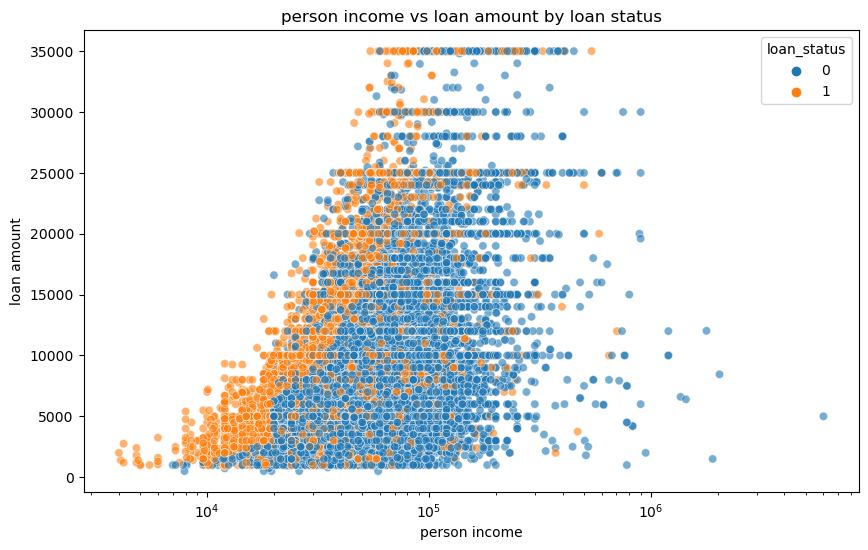

In [13]:
#Bivariate Analysis

#Scatter Plot of person income vs loanamountcolored by loan status
%matplotlib inline
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='person_income', y='loan_amnt', hue='loan_status', alpha=0.6)
plt.xscale('log')
plt.title('person income vs loan amount by loan status')
plt.xlabel('person income')
plt.ylabel('loan amount')
plt.show()

employess earning more that 100,000, tend not to default on the loan. 

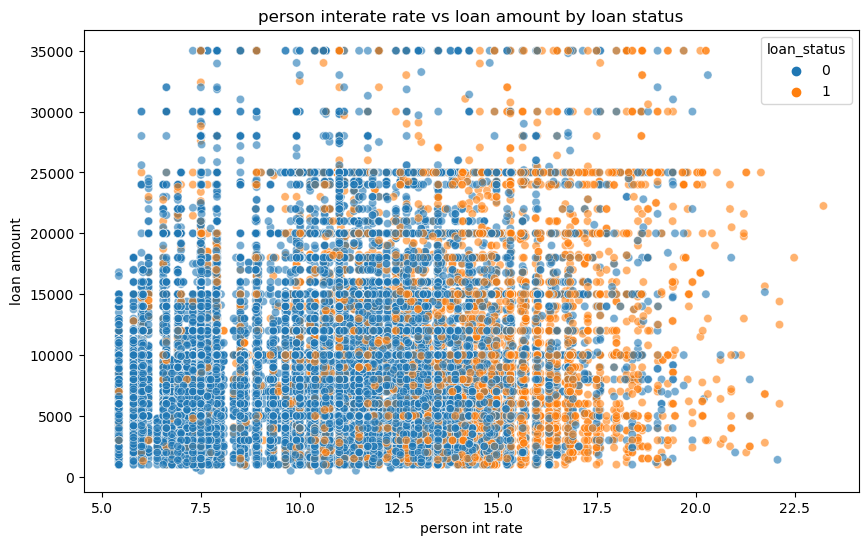

In [14]:
#Scatter Plot of person income vs loanamountcolored by loan status
%matplotlib inline
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='loan_int_rate', y='loan_amnt', hue='loan_status', alpha=0.6)
plt.title('person interate rate vs loan amount by loan status')
plt.xlabel('person int rate')
plt.ylabel('loan amount')
plt.show()

People whose loan has a high interest tend t default as compared to low interest rate

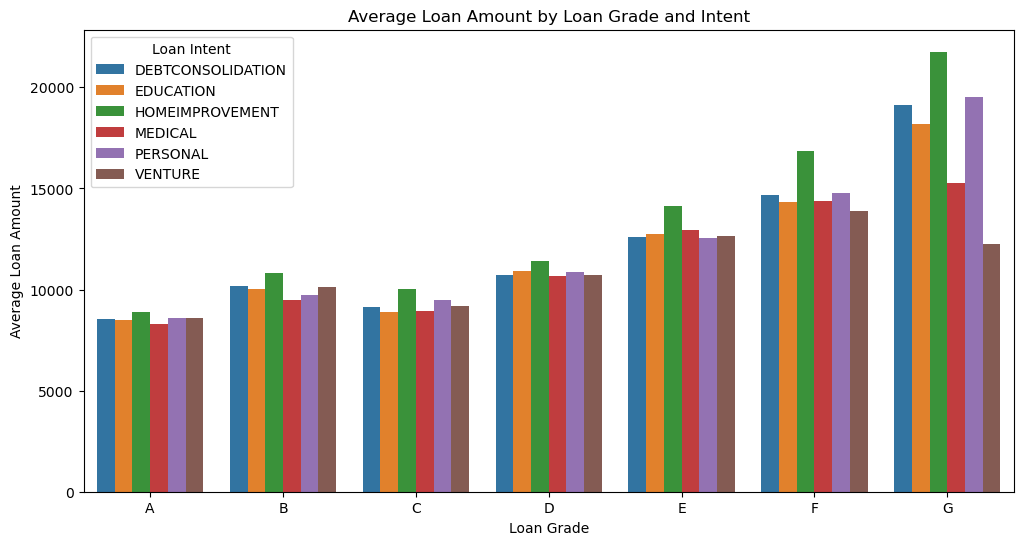

In [15]:
%matplotlib inline
# Aggregate the data
avg_loan_amnt = df.groupby(['loan_grade', 'loan_intent'])['loan_amnt'].mean().reset_index()

# Plot as column chart
plt.figure(figsize=(12, 6))
sns.barplot(data=avg_loan_amnt, x='loan_grade', y='loan_amnt', hue='loan_intent')
plt.title('Average Loan Amount by Loan Grade and Intent')
plt.xlabel('Loan Grade')
plt.ylabel('Average Loan Amount')
plt.legend(title='Loan Intent')
plt.show()

The highest group receiving loan are in the category G. However Venture category G, do not receive as high as Loan Grade F

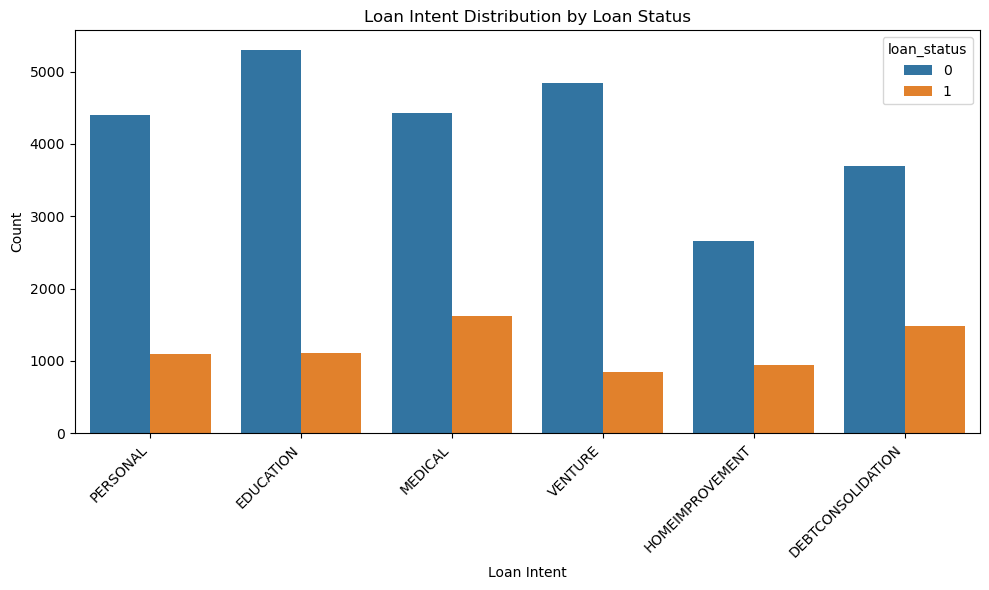

In [16]:
# Bar plot of loan_intent vs loan_status
%matplotlib inline
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='loan_intent', hue='loan_status')
plt.title('Loan Intent Distribution by Loan Status')
plt.xlabel('Loan Intent')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Medical Intent has a high default rate, followed by debt consolidation, education and personal are at per

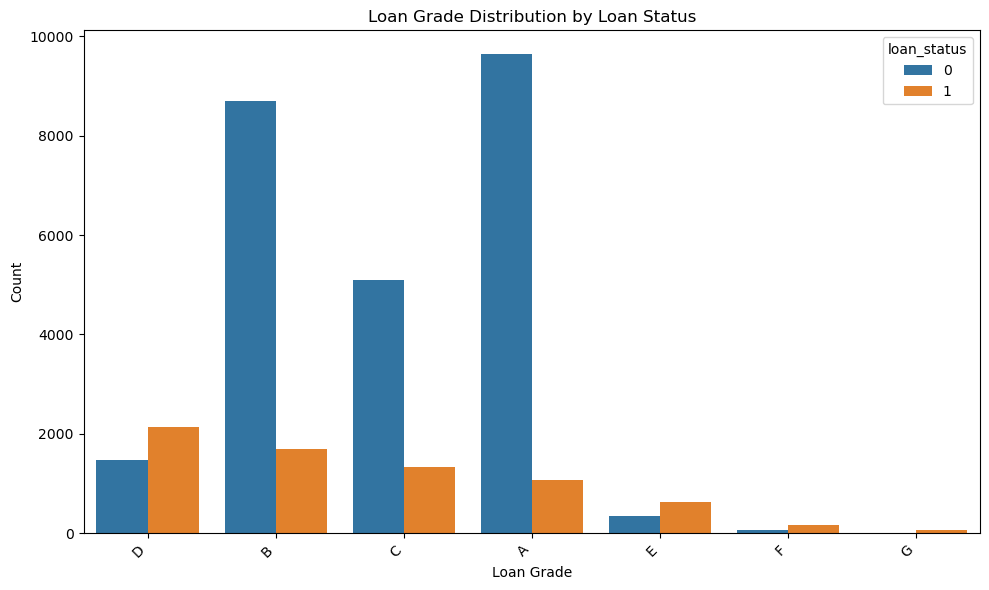

In [17]:
# Bar plot of loan_intent vs loan_status
%matplotlib inline
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='loan_grade', hue='loan_status')
plt.title('Loan Grade Distribution by Loan Status')
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Grade D has a high default rate, then followed by B, c, A , E, F and G. 

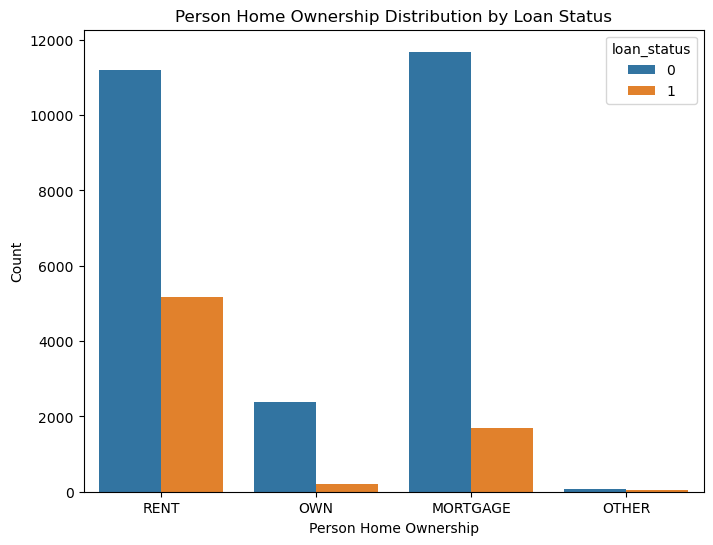

In [18]:
# Bar plot of person_home_ownership vs loan_status
%matplotlib inline
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='person_home_ownership', hue='loan_status')
plt.title('Person Home Ownership Distribution by Loan Status')
plt.xlabel('Person Home Ownership')
plt.ylabel('Count')
plt.show()

People who rent default more as compared to people who own or have a morgage

In [19]:
# Specify the bin edges (change as needed)
bins = [20, 30, 40, 50, 60, 70, 80, 90, 100]
# Create bin labels for display
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89', '90+']

# Assign age to bins
df['age_bins'] = pd.cut(df['person_age'], bins=bins, labels=labels, right=False, include_lowest=True)

c:\Users\Jacqy\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
c:\Users\Jacqy\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


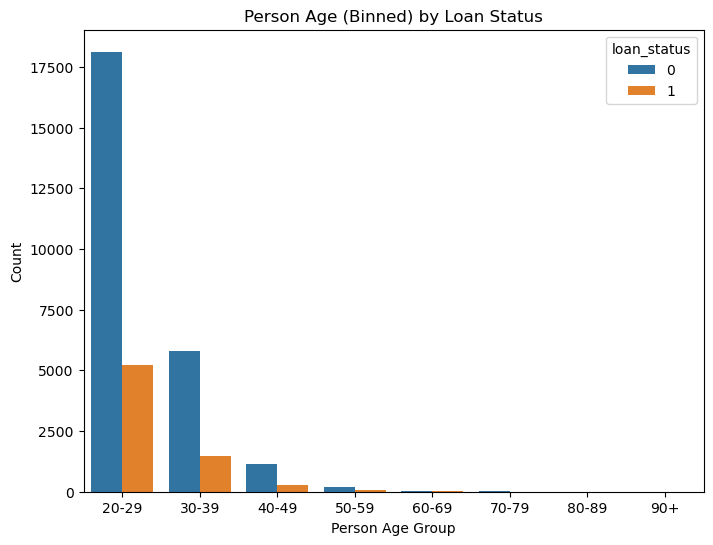

In [20]:
# Bar plot of person_home_ownership vs loan_status
%matplotlib inline
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='age_bins', hue='loan_status')
plt.title('Person Age (Binned) by Loan Status')
plt.xlabel('Person Age Group')
plt.ylabel('Count')
plt.show()

There are more defaulters between the age of 20-29 as compared to other age gaps

employess earning more that 100,000, tend not to default on the loan. 

# Loan Default Analysis Report  

## Key Findings  

1. **Income and Loan Default**  
   - Borrowers with **annual income above 100,000** show **low default rates**.  

2. **Interest Rates and Default Risk**  
   - **High-interest loans** are linked to **higher default rates** compared to low-interest loans.  

3. **Loan Grades**  
   - **Grade G borrowers**: Receive the **highest number of loans** but show a **low default rate**.  
   - **Grade D**: Has the **highest default rate**, followed by **B, C, A, E, F**, with **G being the lowest-risk group** despite high loan counts.  

4. **Loan Purpose**  
   - **Medical expenses** have the **highest default rate**.  
   - **Debt consolidation, education, and personal loans** follow closely with moderate default levels.  

5. **Home Ownership**  
   - **Renters default more often** compared to borrowers who **own homes or have mortgages**.  

6. **Age Factor**  
   - Borrowers aged **20–29 years** represent the **highest default group**, compared to older age groups.  

---

## ✅ Recommendations  

1. **Strengthen Lending to Grade G**  
   - Grade G is a **low-risk, high-volume group**.  
   - Maintain strong support for this group and consider **improved loan terms** to encourage retention and attract similar borrowers.  

2. **Revise Loan Grading Models**  
   - Since Grade D (and even B/C) show higher defaults while Grade G performs strongly, **reassess the loan grading framework**.  
   - Align grading with **actual observed repayment performance** rather than only predicted risk.  

3. **Income-Based Risk Mitigation**  
   - Provide **favorable terms** for borrowers with **income above 100,000**, as they present lower risk.  

4. **Interest Rate Policy**  
   - Instead of setting **very high rates** for high-risk borrowers (which increases defaults), use a **tiered risk assessment model** based on:  
     - Income  
     - Employment length  
     - Loan purpose  

5. **Loan Purpose Risk Control**  
   - For **medical and debt consolidation loans** (highest default risk):  
     - Set **stricter eligibility criteria**.  
     - Offer **smaller loan amounts**.  
     - Explore **insurance-backed or co-signed lending options**.  

6. **Home Ownership as a Risk Indicator**  
   - Treat **home ownership** as a strong predictor of repayment.  
   - Offer more favorable terms to homeowners and **closely monitor renters**.  

7. **Age-Specific Lending Strategy**  
   - Young borrowers (20–29) are **most prone to default**.  
   - Consider:  
     - Smaller loan allocations for this group.  
     - Financial literacy programs.  
     - Encouraging **co-signers** to reduce default risk.  

---

## 📌 Strategic Takeaway  
> Lending expansion should focus on **Grade G borrowers, high-income applicants, and homeowners**.  
> At the same time, introduce **tighter controls for high-risk purposes (medical, debt consolidation) and younger age groups**.  
> Updating the **loan grading system** to reflect real-world repayment patterns will improve accuracy, reduce defaults, and enhance profitability.  





In [21]:
df.nunique()

person_age                      58
person_income                 4295
person_home_ownership            4
person_emp_length               36
loan_intent                      6
loan_grade                       7
loan_amnt                      753
loan_int_rate                  349
loan_status                      2
loan_percent_income             77
cb_person_default_on_file        2
cb_person_cred_hist_length      29
age_bins                         8
dtype: int64

C:\Users\Jacqy\AppData\Local\Temp\ipykernel_17224\2206331976.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\Jacqy\AppData\Local\Temp\ipykernel_17224\2206331976.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\Jacqy\AppData\Local\Temp\ipykernel_17224\2206331976.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\Jacqy\AppData\Local\Temp\ipykernel_17224\2206331976.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\Jacqy\AppData\Local\Temp\ipykernel_17224\2206331976.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
C:\Users\Jacqy\AppData\Local\Temp\ipykernel_17224\2206331976.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


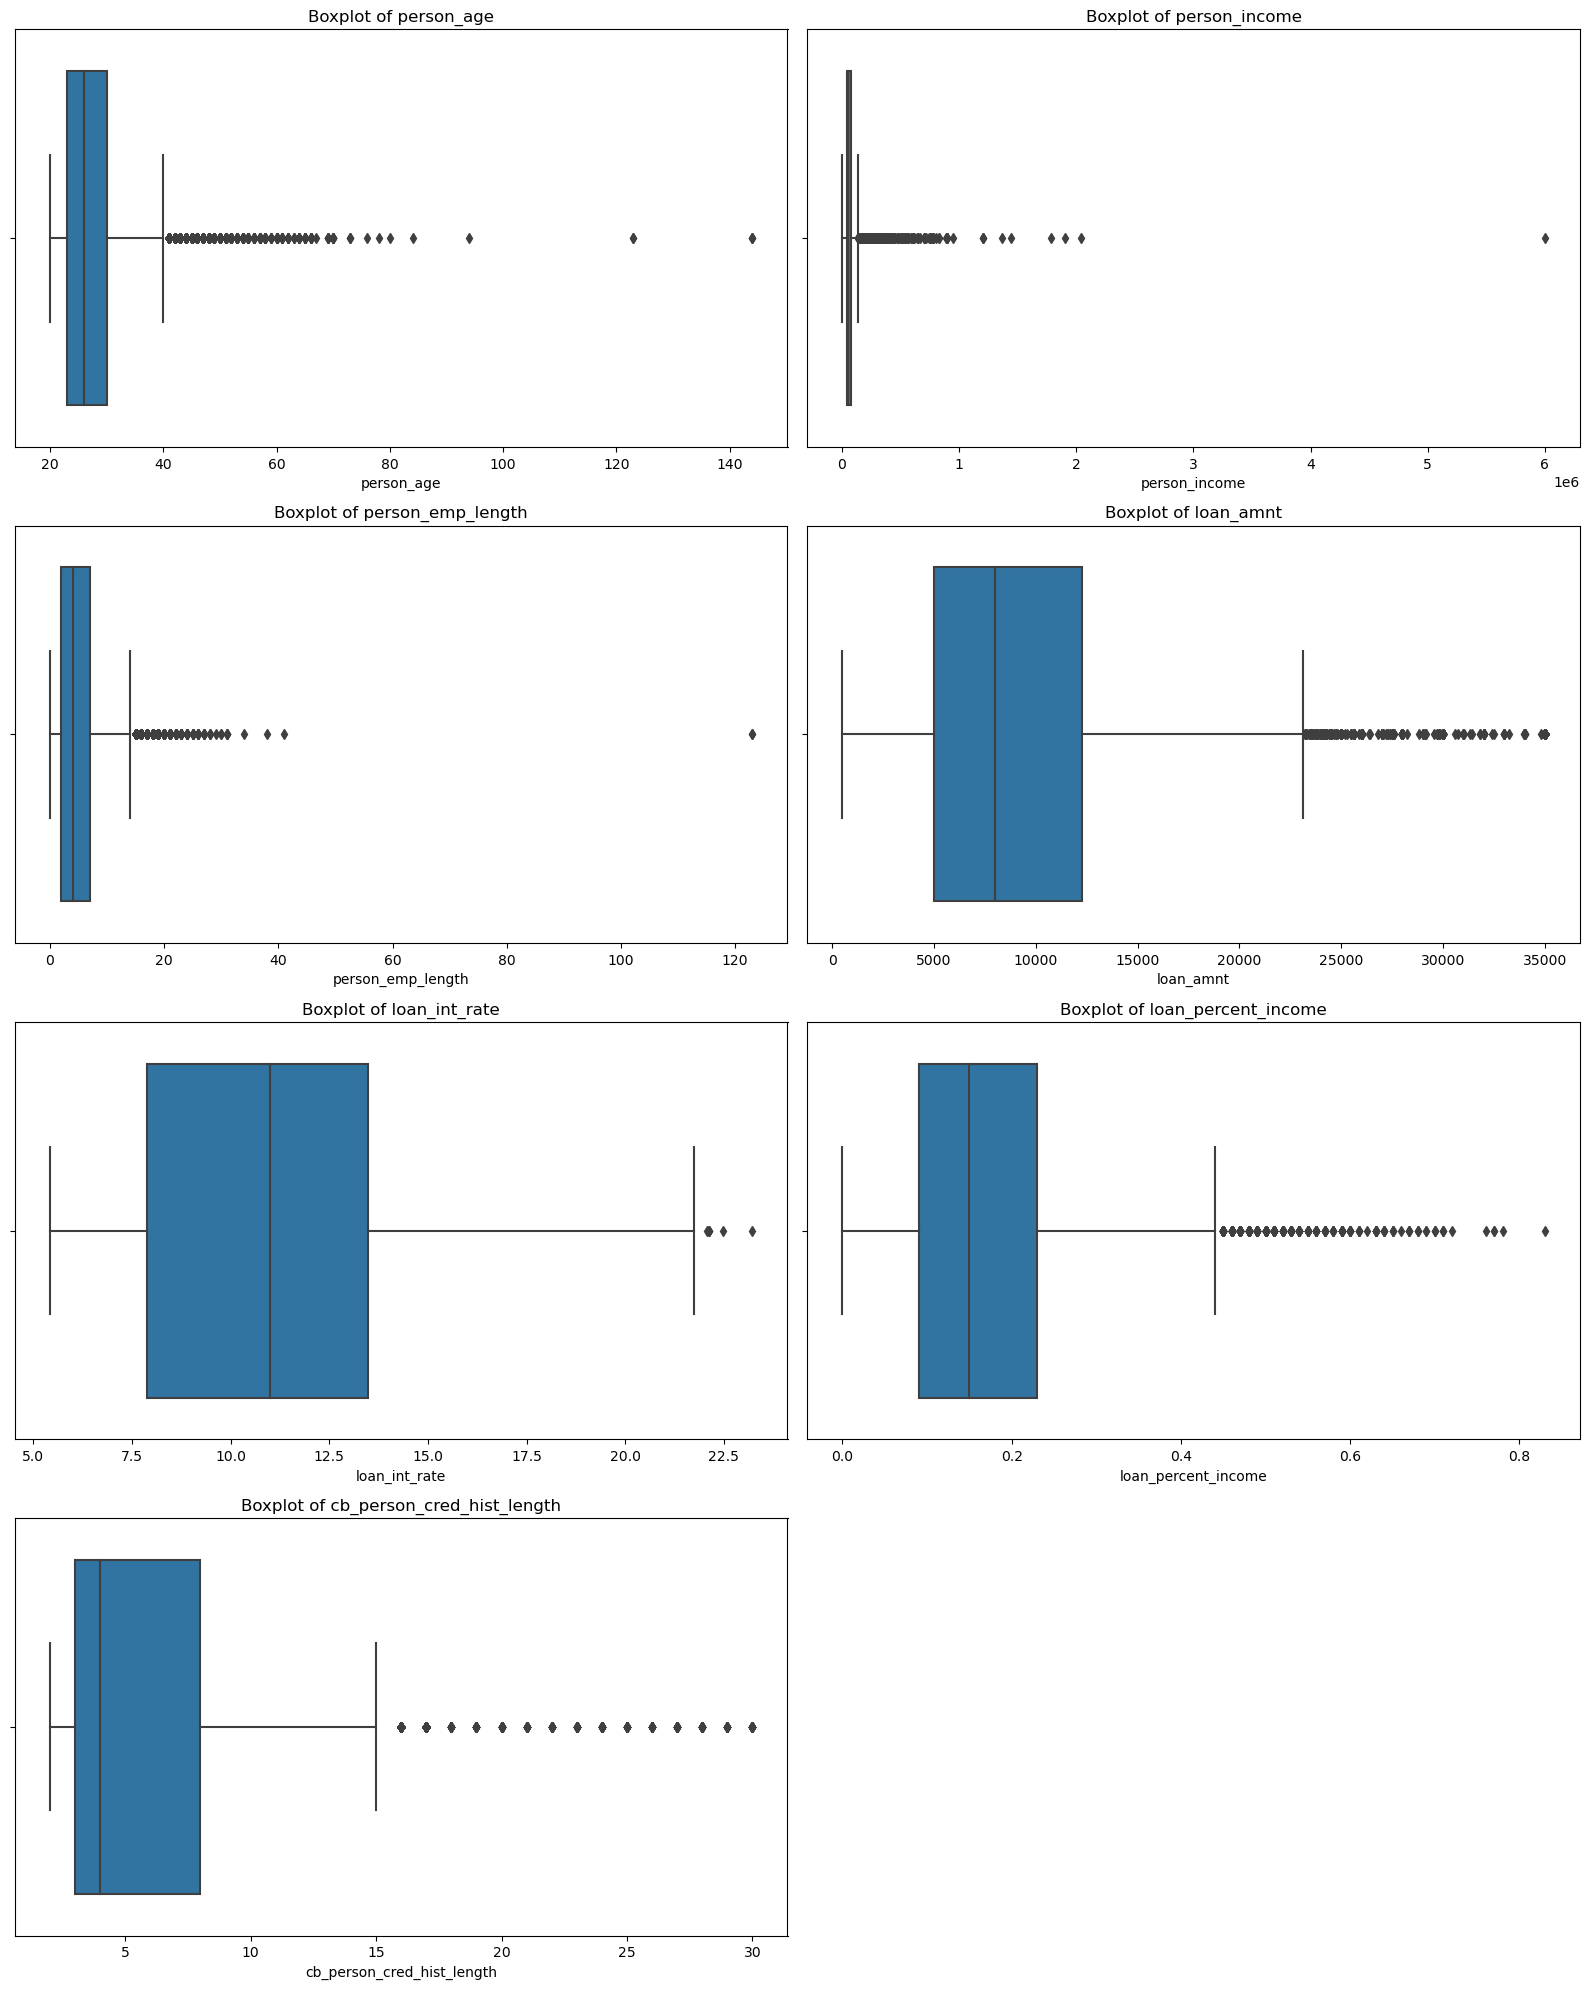

In [22]:
# List of continuous columns to check
continuous_cols = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length'
]

# Set up the plotting area
plt.figure(figsize=(16, 20))

# Loop through and plot boxplots
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()

### Outlier Analysis based on Boxplots

The boxplots for the continuous features reveal the presence of outliers in several columns:

- **person_age**: There are outliers with unusually high ages, including one extreme value around 140.
- **person_income**: The boxplot shows a significant number of outliers with very high incomes, indicating a skewed distribution towards higher income values.
- **person_emp_length**: There is a prominent outlier with a very high employment length (around 120 years), which seems unrealistic and is likely a data entry error. There are also other outliers with high employment lengths.
- **loan_amnt**: While there's a range of loan amounts, the boxplot indicates some outliers with higher loan amounts than the majority of the data.
- **loan_int_rate**: There are outliers with higher interest rates, which is expected as interest rates can vary.
- **loan_percent_income**: The boxplot shows outliers where the loan amount is a very high percentage of the person's income, suggesting potentially risky loans.
- **cb_person_cred_hist_length**: There are outliers with significantly longer credit history lengths than the average.

These outliers should be investigated further to determine if they are data errors or valid extreme values. Depending on the analysis goals and the nature of the outliers, strategies like removal, transformation, or Winsorizing might be considered during data preprocessing.  

The one of concern is employment month  and the age.

AgeInfer = df[df['person_age'] == 123]

In [23]:
AgeInfer = df[(df['person_age'] == 123) | (df['person_age'] == 144)]
AgeInfer


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_bins
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3,NaN
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2,NaN
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3,NaN
747,123,78000,RENT,7.0,VENTURE,B,20000,10.99,0,0.26,N,4,NaN
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25,NaN


Unrealistic ages	123 and 144 are not valid human ages.
Income outlier	6,000,000 is far above the rest, likely an entry error.

In [24]:
EMPLENG = df[df['person_emp_length'] == 123]
EMPLENG

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_bins
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,20-29
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4,20-29


person_emp_length
123.0
Unrealistically high for age 21–22 → anomaly

In [25]:
# Keep rows where age is between 18 and 100, tehre are five extreme values of 144 1nd 123 hence just drop the rows

# There are only two extreme values of 123, then we just drop the rows

# Drop rows where age is NOT between 18 and 100
df = df[(df['person_age'] >= 18) & (df['person_age'] <= 100)]

# Drop rows where employment length is NOT reasonable
# Example: drop where emp_length == 123 (your extreme case)
df = df[df['person_emp_length'] != 123]


In [26]:
df.shape

(32409, 13)

In [27]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_bins
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,20-29
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,20-29
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,20-29
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,20-29
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,20-29


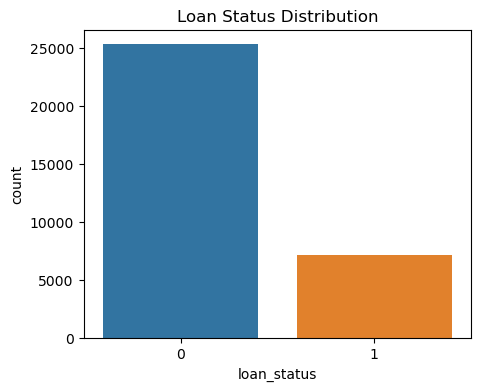

In [28]:
#visualise  target values

if 'loan_status' in df.columns:
  plt.figure(figsize=(5,4))
  sns.countplot(x='loan_status', data=df)
  plt.title('Loan Status Distribution')
  plt.show()


In [29]:
#encode categorical column for visualisation
le = LabelEncoder()
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
  df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
# Encode 'age_bins' or any remaining object-type columns
df_encoded['age_bins'] = le.fit_transform(df_encoded['age_bins'].astype(str))


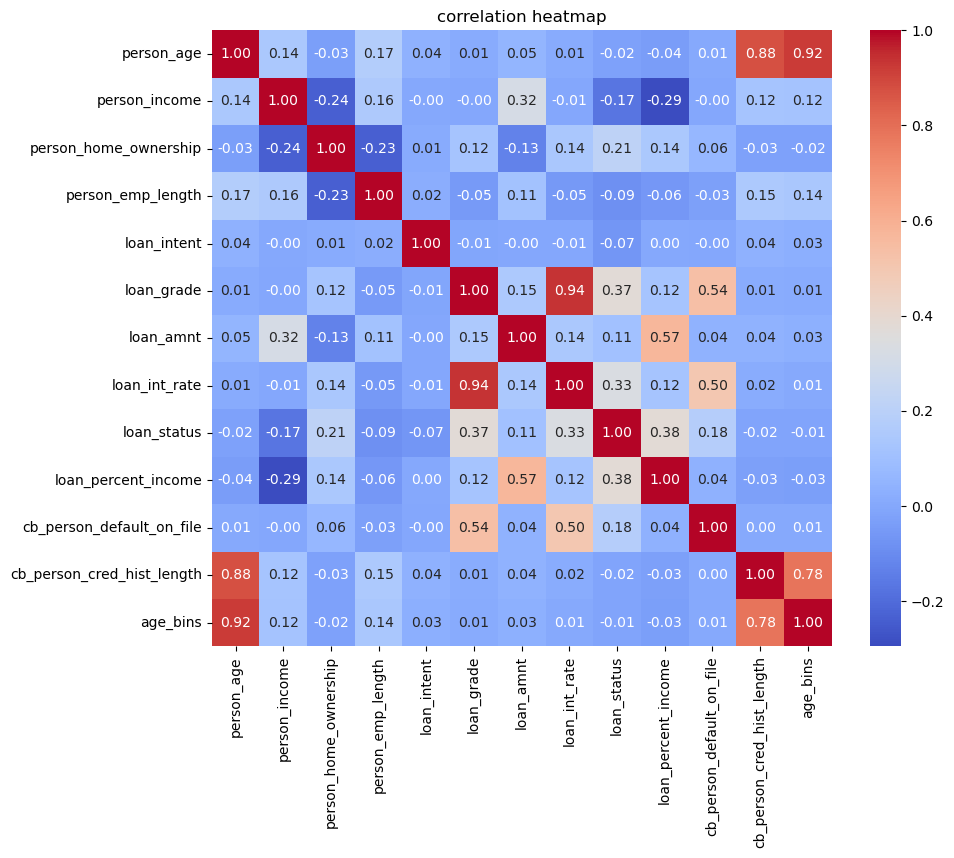

In [30]:
#correlation Heatmap

plt.figure(figsize=((10,8)))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('correlation heatmap')
plt.show()


a function that shows correlation between variable. 

In [31]:
# Separate features and target
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Calculate mutual information
mi_scores = mutual_info_classif(X, y, discrete_features='auto')
mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False)

# Display
print(mi_df)

                       Feature  MI Score
1                person_income  0.113640
8          loan_percent_income  0.082950
7                loan_int_rate  0.076052
5                   loan_grade  0.075437
2        person_home_ownership  0.034743
9    cb_person_default_on_file  0.014182
6                    loan_amnt  0.012172
4                  loan_intent  0.010045
3            person_emp_length  0.005312
10  cb_person_cred_hist_length  0.000663
0                   person_age  0.000000
11                    age_bins  0.000000


### Key Findings from EDA

Based on the exploratory data analysis performed, here are some key observations:

*   **Missing Values**: The dataset initially contained missing values in `person_emp_length` and `loan_int_rate`. These were addressed by imputing with the median values.
*   **Outliers**: Outliers were identified in several continuous features, particularly in `person_age`, `person_income`, and `person_emp_length`. Filtering was applied to remove extreme outliers in `person_age` (ages outside 18-100) and `person_emp_length` (employment length outside 0-50 years).
*   **Target Variable Distribution**: The `loan_status` variable is imbalanced, with a significantly higher number of non-defaulting loans (0) compared to defaulting loans (1). This was addressed later using SMOTE during model training.
*   **Relationship between Income and Loan Amount**: The scatter plot of `person_income` vs `loan_amnt` suggests that individuals with higher incomes tend to take out larger loans. The loan status is somewhat mixed across income and loan amount ranges.
*   **Relationship between Interest Rate and Loan Amount**: The scatter plot of `loan_int_rate` vs `loan_amnt` shows a general trend where higher interest rates are associated with a wider range of loan amounts, and defaulting loans appear to be more spread out across different interest rates.
*   **Loan Grade and Intent**: The bar plot of average loan amount by loan grade and intent shows variations in average loan amounts across different grades and intentions. Loan grades seem to be related to the average loan amount.
*   **Categorical Feature Distributions**:
    *   `loan_intent`: Personal, Education, and Medical loans are the most frequent loan intents. Default rates appear to vary across different loan intents.
    *   `loan_grade`: Grades A and B are the most common. Higher loan grades (like F and G) have a higher proportion of defaulting loans.
    *   `person_home_ownership`: Rent and Mortgage are the most frequent home ownership statuses. Default rates are observed across all home ownership types.
    *   `person_age` (Binned): Loan status distribution varies across different age groups.
*   **Correlation**: The heatmap shows the correlation between the encoded features. Some features show moderate correlations with each other.
*   **Mutual Information**: The mutual information analysis highlighted `person_income`, `loan_percent_income`, `loan_int_rate`, and `loan_grade` as the top features with the highest dependency on the target variable `loan_status`.

In [33]:
#Identifying the variables that are highly correlated
highly_correlated_variables_df = (
    df
    .select_dtypes(include=['number'])   # only keep numeric columns
    .corr()
    .abs()
    .stack()
    .reset_index()
    .sort_values(0, ascending=False)
)
highly_correlated_variables_df['variable_pairs'] = list(zip(highly_correlated_variables_df.level_0, highly_correlated_variables_df.level_1))
highly_correlated_variables_df = highly_correlated_variables_df.set_index('variable_pairs').drop(columns=['level_1', 'level_0'])
highly_correlated_variables_df.columns = ['correlation_coefficient']
highly_correlated_variables_df = highly_correlated_variables_df.drop_duplicates()

filter_condition = (highly_correlated_variables_df.correlation_coefficient > 0.75) & (highly_correlated_variables_df.correlation_coefficient < 1)
highly_correlated_variables_df[filter_condition]

,correlation_coefficient
variable_pairs,
"(person_age, cb_person_cred_hist_length)",0.87824


In [38]:
df = df.drop(columns=['cb_person_cred_hist_length', 'age_bins'])

# Check remaining columns
print(df.columns.tolist())


['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file']


In [39]:
# X_top contains only top 4 features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
print(X_train_scaled)

[[ 1.51000554  0.36541275 -1.16843216 ... -0.4658342   2.52687487
   1.05182298]
 [-0.43669407 -0.30076776  0.92369081 ... -0.4658342  -0.44332914
  -0.55082244]
 [-0.2744691   0.46058139 -1.16843216 ... -0.4658342  -0.69084614
  -0.55082244]
 ...
 [ 1.83445547 -0.11043047  0.92369081 ... -0.4658342   2.03184087
   1.05182298]
 [ 0.37443077  2.17361699 -1.16843216 ... -0.4658342   0.05170487
   1.05182298]
 [-0.59891904 -0.62434115  0.22631649 ...  2.14668652 -0.69084614
  -0.55082244]]


In [42]:
 #apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [43]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machines": SVC(),
    "Decision Trees": DecisionTreeClassifier(),
    "Random Forests": RandomForestClassifier()
}

# Train & evaluate
results = {}
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    score = model.score(X_test_scaled, y_test)  # X_test_scaled is NumPy
    results[name] = score

# Print sorted results
print("Model Accuracy Scores:")
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}")

Model Accuracy Scores:
Random Forests: 0.9283
Decision Trees: 0.8766
Support Vector Machines: 0.8547
K-Nearest Neighbors: 0.7945
Logistic Regression: 0.7817


In [44]:
param_grids = {
    "Logistic Regression": [
        {
            "solver": ["lbfgs", "liblinear", "saga"],
            "penalty": ["l1", "l2", "elasticnet", None],
            "C": [0.1, 1, 10],
            "max_iter": [500],
            "l1_ratio": [0, 0.5, 1]  # only used with saga + elasticnet
        }
    ],
    "K-Nearest Neighbors": {
        "n_neighbors": [3, 5, 7],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    },
    "Support Vector Machines": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    },
    "Decision Trees": {
        "criterion": ["gini", "entropy"],
        "max_depth": [None, 10],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    },
    "Random Forests": {
        "n_estimators": [100, 200],
        "criterion": ["gini", "entropy"],
        "max_depth": [None, 10],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt"]
    }
}


from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
results = {}
best_params = {}

for name, model in models.items():
    print(f"\nRunning hyperparameter tuning for {name}...")

    if name in ["Logistic Regression", "Support Vector Machines", "Random Forests"]:
        search = RandomizedSearchCV(
            model,
            param_distributions=param_grids[name],
            n_iter=10,   # smaller sample for speed
            cv=5,
            scoring="accuracy",
            n_jobs=-1,
            random_state=42,
            error_score=np.nan
        )
    else:
        search = GridSearchCV(
            model,
            param_grids[name],
            cv=5,
            scoring="accuracy",
            n_jobs=-1,
            error_score=np.nan
        )

    search.fit(X_train_resampled, y_train_resampled)
    best_params[name] = search.best_params_
    results[name] = search.score(X_test_scaled, y_test)

print("\nModel Accuracy Scores (Best Results):")
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name}: {score:.4f}  |  Best Params: {best_params[name]}")



Running hyperparameter tuning for Logistic Regression...


c:\Users\Jacqy\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Jacqy\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Jacqy\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Jacqy\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver = _c


Running hyperparameter tuning for K-Nearest Neighbors...

Running hyperparameter tuning for Support Vector Machines...

Running hyperparameter tuning for Decision Trees...

Running hyperparameter tuning for Random Forests...

Model Accuracy Scores (Best Results):
Random Forests: 0.9306  |  Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'entropy'}
Decision Trees: 0.8883  |  Best Params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Support Vector Machines: 0.8695  |  Best Params: {'kernel': 'rbf', 'gamma': 'auto', 'C': 10}
K-Nearest Neighbors: 0.8283  |  Best Params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Logistic Regression: 0.7815  |  Best Params: {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 500, 'l1_ratio': 0, 'C': 0.1}


In [ ]:
# Weighted recall scorer (works for imbalanced classes and multi-class)
recall_scorer = make_scorer(recall_score, average="weighted")
metrics_summary = {}

for name, model in models.items():
    print(f"\nRunning hyperparameter tuning for {name}...")

    if name in ["Logistic Regression", "Support Vector Machines", "Random Forests"]:
        search = RandomizedSearchCV(
            model,
            param_distributions=param_grids[name],
            n_iter=10,
            cv=5,
            scoring=recall_scorer,   # ✅ recall over precision
            n_jobs=-1,
            random_state=42,
            error_score=np.nan
        )
    else:
        search = GridSearchCV(
            model,
            param_grids[name],
            cv=5,
            scoring=recall_scorer,
            n_jobs=-1,
            error_score=np.nan
        )

    search.fit(X_train_resampled, y_train_resampled)
    y_pred = search.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    if len(set(y_test)) == 2 and hasattr(search, "predict_proba"):
        y_proba = search.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None

    metrics_summary[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,   # ✅ this should be higher now
        "F1 Score": f1,
        "AUC": auc
    }

print("\nModel Performance Summary:")
for name, metrics in metrics_summary.items():
    print(f"\n{name} | Best Params: {search.best_params_}")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")



Running hyperparameter tuning for Logistic Regression...


c:\Users\Jacqy\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Jacqy\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Jacqy\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Jacqy\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver = _c


Running hyperparameter tuning for K-Nearest Neighbors...

Running hyperparameter tuning for Support Vector Machines...


In [44]:
# Results storage
metrics_results = []

for name, model in best_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred)

    metrics_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "AUC-ROC": auc_roc
    })

# Create DataFrame
metrics_df = pd.DataFrame(metrics_results).sort_values(by="Accuracy", ascending=False)

print("\nEvaluation Metrics for All Models:")
print(metrics_df)


Evaluation Metrics for All Models:
                     Model  Accuracy  Precision    Recall  F1 Score   AUC-ROC
0           Random Forests  0.933817   0.970504  0.719323  0.826245  0.856601
1           Decision Trees  0.909133   0.810953  0.762341  0.785896  0.856289
4      Logistic Regression  0.844955   0.730726  0.461213  0.565499  0.706811
3      K-Nearest Neighbors  0.841407   0.652106  0.589563  0.619259  0.750745
2  Support Vector Machines  0.812712   0.911290  0.159379  0.271309  0.577518


 (recall-flag defaulters, ) improve the model(scores), recall to be more than the precision. 

In [1]:
# 1️⃣ Class weight to emphasize minority class
rf_recall = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # ⚡ give more weight to minority class
    random_state=42
)

rf_recall.fit(X_train, y_train)

# 2️⃣ Lower threshold instead of using 0.5
y_proba = rf_recall.predict_proba(X_test_scaled)[:, 1]
threshold = 0.3  # ⚡ lower threshold to increase recall
y_pred_custom = (y_proba >= threshold).astype(int)

# 3️⃣ Evaluate
metrics_recall = {
    "Accuracy": accuracy_score(y_test, y_pred_custom),
    "Precision": precision_score(y_test, y_pred_custom),
    "Recall": recall_score(y_test, y_pred_custom),
    "F1": f1_score(y_test, y_pred_custom),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))

# 4️⃣ See scores
print("\n📊 Metrics:\n", pd.Series(metrics_recall))

NameError: name 'RandomForestClassifier' is not defined


### Metric Explanations

- **Accuracy**:  
  The model achieved an accuracy of **0.9338** (93.38%).  
  This means that most predictions were correct, but accuracy alone can be misleading with imbalanced datasets.

- **Precision**:  
  Precision is **0.9705**.  
  When the model predicts a loan will default, it is correct **97.05% of the time**.  
  High precision = very few healthy loans misclassified as risky (low false positives).

- **Recall (Sensitivity)**:  
  Recall is **0.7193**.  
  The model correctly identified **71.93% of all defaulting loans**.  
  This indicates the model misses ~28% of defaults (false negatives).

- **F1-score**:  
  The F1-score is **0.8262**, balancing precision and recall.  
  This shows the model is both highly precise and reasonably good at capturing defaults.

- **AUC-ROC**:  
  The model achieved an **AUC-ROC of 0.8566**, indicating **good discriminatory power**.  
  It reliably separates defaulting vs. non-defaulting loans across thresholds.  
  (0.5 = random guessing, 1.0 = perfect model).



### Summary
The Random Forest model performs **strongly overall**:
- **High accuracy & excellent precision** → very few false positives.  
- **Moderate recall** → some defaults are missed.  
- **Good balance (F1-score)** and **solid AUC-ROC** → effective at distinguishing loan outcomes.  

In [45]:
# Instantiate the best model from Step 4 (e.g., Random Forests)
best_model = RandomForestClassifier(n_estimators=200, max_depth=30)

# Create the RFECV object and fit it to the training data
selector = RFECV(best_model, step=1, cv=5, scoring='accuracy')
selector.fit(X_train_resampled, y_train_resampled)

# Get the selected features and their ranks
# If X_train_resampled is a NumPy array, convert it back to DataFrame:
X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=X_train.columns)

# Then use the DataFrame to get selected features
selected_features = X_train_resampled_df.columns[selector.support_]
feature_ranks = selector.ranking_

print(f"Selected features: {selected_features}")
print(f"Feature ranks: {feature_ranks}")

Selected features: Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'age_bins'],
      dtype='object')
Feature ranks: [1 1 1 1 1 1 1 1 1 1 1 1]


In [50]:
# Step 1: RFECV on true training data
rf_true = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42)

selector_true = RFECV(rf_true, step=1, cv=5, scoring="accuracy", n_jobs=-1)
selector_true.fit(X_train, y_train)   # 👈 TRUE data (no resampling)

# Step 2: Get selected features
X_train_df = pd.DataFrame(X_train, columns=X_train.columns)
selected_features_true = X_train_df.columns[selector_true.support_]

print("Selected Features (True Data):", list(selected_features_true))

Selected Features (True Data): ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income']


Confusion Matrix (Random Forest):
 [[5033   31]
 [ 398 1020]]


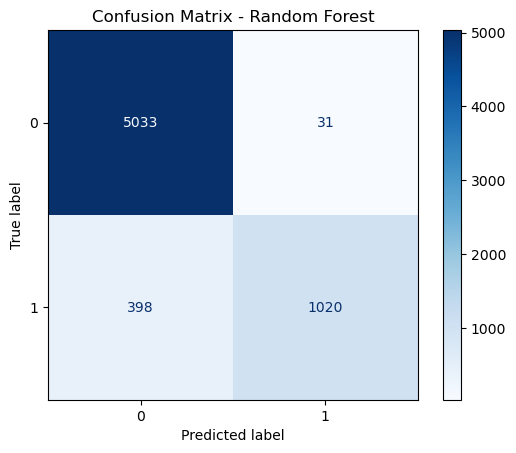

In [49]:
# Predict with Random Forest
rf_model = best_models["Random Forests"]
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix (Random Forest):\n", cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest")
plt.show()

### Confusion Matrix Explained

The confusion matrix provides a detailed breakdown of the model's predictions compared to the actual values. It is particularly useful for understanding the performance of a classification model, especially when dealing with imbalanced datasets.

Based on the confusion matrix shown in the output of the previous cell:

*   **True Negatives (TN)**: The top-left cell shows that the model correctly predicted **5033** non-defaulting loans.
*   **False Positives (FP)**: The top-right cell shows that the model incorrectly predicted **31** non-defaulting loans as defaulting.
*   **False Negatives (FN)**: The bottom-left cell shows that the model incorrectly predicted **398** defaulting loans as non-defaulting.
*   **True Positives (TP)**: The bottom-right cell shows that the model correctly predicted **1020** defaulting loans.

In summary, the model is better at identifying non-defaulting loans (high TN) than defaulting loans (lower TP). There is a notable number of false positives, meaning some healthy loans are being flagged as risky, and a significant number of false negatives, meaning some risky loans are being missed. This aligns with the precision and recall scores, where precision is lower than recall, indicating a higher rate of false positives compared to false negatives among the positive predictions.

test a model pre production. (process), deployment by streamlit or notebook